In [ ]:
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

print(torch.cuda.get_device_name(0))  # should print H100
print(torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

NVIDIA A100-SXM4-40GB
42.405855232 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
# Drive already mounted — verify it's accessible
print(os.path.exists("/content/drive/MyDrive/OCR"))

True


In [ ]:
os.makedirs("/content/drive/MyDrive/OCR", exist_ok=True)

transform_fixed = T.Compose([
    T.ToTensor(),
    T.Lambda(lambda x: torch.rot90(x, k=3, dims=[1, 2])),
    T.Lambda(lambda x: torch.flip(x, dims=[2])),
    T.Normalize((0.1736,), (0.3317,))
])

Device: cuda


100%|██████████| 562M/562M [00:02<00:00, 225MB/s]


Train: 697932 | Test: 116323 | Classes: 62


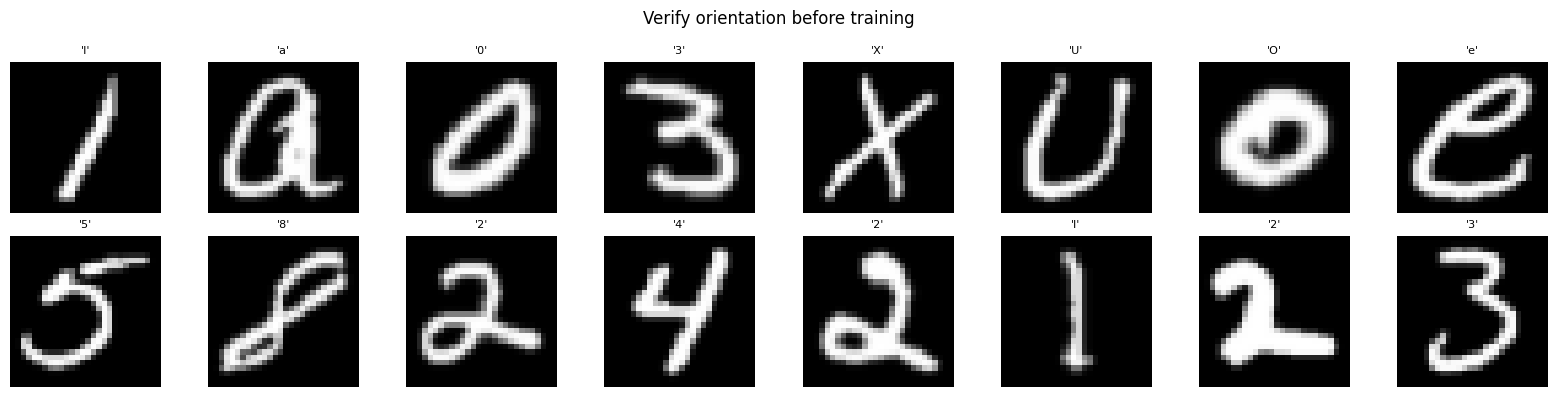

Parameters: 1,761,310
Epoch 01/60 | Train: 0.8283 | Val: 0.8625
  --> Saved (0.8625)
Epoch 02/60 | Train: 0.8534 | Val: 0.8649
  --> Saved (0.8649)
Epoch 03/60 | Train: 0.8579 | Val: 0.8664
  --> Saved (0.8664)
Epoch 04/60 | Train: 0.8598 | Val: 0.8676
  --> Saved (0.8676)
Epoch 05/60 | Train: 0.8610 | Val: 0.8697
  --> Saved (0.8697)
Epoch 06/60 | Train: 0.8617 | Val: 0.8686
  No improvement 1/5
Epoch 07/60 | Train: 0.8626 | Val: 0.8686
  No improvement 2/5
Epoch 08/60 | Train: 0.8635 | Val: 0.8676
  No improvement 3/5
Epoch 09/60 | Train: 0.8702 | Val: 0.8742
  --> Saved (0.8742)
Epoch 10/60 | Train: 0.8709 | Val: 0.8759
  --> Saved (0.8759)
Epoch 11/60 | Train: 0.8713 | Val: 0.8743
  No improvement 1/5
Epoch 12/60 | Train: 0.8716 | Val: 0.8749
  No improvement 2/5
Epoch 13/60 | Train: 0.8716 | Val: 0.8757
  No improvement 3/5
Epoch 14/60 | Train: 0.8766 | Val: 0.8789
  --> Saved (0.8789)
Epoch 15/60 | Train: 0.8775 | Val: 0.8783
  No improvement 1/5
Epoch 16/60 | Train: 0.8777 | Val

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Transform with orientation fix ───────────────────────────
transform = T.Compose([
    T.ToTensor(),
    T.Lambda(lambda x: torch.rot90(x, k=3, dims=[1, 2])),
    T.Lambda(lambda x: torch.flip(x, dims=[2])),
    T.Normalize((0.1736,), (0.3317,))
])

# ── Download dataset ──────────────────────────────────────────
DATA_DIR = "./emnist_data"
SPLIT    = "byclass"

full_train = datasets.EMNIST(
    root=DATA_DIR, split=SPLIT,
    train=True, download=True, transform=transform
)
test_ds = datasets.EMNIST(
    root=DATA_DIR, split=SPLIT,
    train=False, download=True, transform=transform
)

print(f"Train: {len(full_train)} | Test: {len(test_ds)} | Classes: {len(full_train.classes)}")

# ── Verify orientation ────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img, label = test_ds[i]
    ax.imshow(img.squeeze().numpy() * 0.3317 + 0.1736, cmap="gray")
    ax.set_title(f"'{full_train.classes[label]}'", fontsize=8)
    ax.axis("off")
plt.suptitle("Verify orientation before training")
plt.tight_layout()
plt.show()

# ── Split + loaders ───────────────────────────────────────────
val_size   = int(0.1 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=2)

# ── Model ─────────────────────────────────────────────────────
class CharCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.15),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

num_classes = len(full_train.classes)
model       = CharCNN(num_classes).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Training ──────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)
SAVE_PATH = "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth"

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            out  = model(images)
            loss = criterion(out, labels)
            if is_train:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

best_val_acc      = 0.0
epochs_no_improve = 0
EPOCHS, PATIENCE  = 60, 5

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader)
    scheduler.step(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc      = val_acc
        epochs_no_improve = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_acc":          val_acc,
            "split":            SPLIT,
            "num_classes":      num_classes,
            "classes":          list(full_train.classes),
            "transform":        "rot90_k3_flip_normalize",
        }, SAVE_PATH)
        print(f"  --> Saved ({val_acc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement {epochs_no_improve}/{PATIENCE}")
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print(f"\nBest val acc: {best_val_acc:.4f}")
print(f"Saved to: {SAVE_PATH}")

In [ ]:
import os
path = "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth"
if os.path.exists(path):
    size = os.path.getsize(path) / 1024 / 1024
    print(f"Found: {size:.1f} MB")
else:
    print("Not found — may still be syncing to Drive")
    # List all files to confirm
    print(os.listdir("/content/drive/MyDrive/OCR"))

Found: 6.7 MB


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import matplotlib.pyplot as plt

try:
    from skimage.filters import threshold_sauvola
    SKIMAGE_AVAILABLE = True
except ImportError:
    SKIMAGE_AVAILABLE = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── CharCNN ───────────────────────────────────────────────────
class CharCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.15),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# ── Load CNN weights ──────────────────────────────────────────
CNN_PATH    = "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth"
ckpt        = torch.load(CNN_PATH, map_location=device, weights_only=False)
NUM_CLASSES = ckpt["num_classes"]
EMNIST_CHARS = ckpt["classes"]
IDX_TO_CHAR  = {i: ch for i, ch in enumerate(EMNIST_CHARS)}

cnn_model = CharCNN(NUM_CLASSES).to(device)
cnn_model.load_state_dict(ckpt["model_state_dict"])
cnn_model.eval()
print(f"CNN loaded — val_acc: {ckpt['val_acc']:.4f} | classes: {NUM_CLASSES}")
print(f"Transform used: {ckpt.get('transform', 'check training file')}")

Device: cuda
CNN loaded — val_acc: 0.8838 | classes: 62
Transform used: rot90_k3_flip_normalize


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Then verify the file exists
import os
files = [f for f in os.listdir("/content/drive/MyDrive/OCR") if f.endswith(".pth")]
print("Available weights:", files)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Available weights: ['emnist_cnn_best.pth', 'finetuned_cnn.pth', 'emnist_cnn_byclass.pth', 'char74k_finetuned_cnn.pth', 'emnist_cnn_byclass_2.pth']


In [ ]:
import os
import time

path = "/content/drive/MyDrive/OCR"
files = [f for f in os.listdir(path) if f.endswith(".pth")]

for f in files:
    full_path = os.path.join(path, f)
    size      = os.path.getsize(full_path) / 1024 / 1024
    modified  = time.ctime(os.path.getmtime(full_path))
    print(f"  {f}: {size:.1f} MB | {modified}")

  emnist_cnn_best.pth: 6.7 MB | Tue Apr 21 14:56:07 2026
  finetuned_cnn.pth: 6.7 MB | Fri Apr 24 21:07:07 2026
  emnist_cnn_byclass.pth: 6.7 MB | Fri Apr 24 22:14:21 2026
  char74k_finetuned_cnn.pth: 6.7 MB | Sat Apr 25 12:29:52 2026
  emnist_cnn_byclass_2.pth: 6.7 MB | Sat Apr 25 19:57:48 2026


In [ ]:
# Load new weights
CNN_PATH     = "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth"
emnist_ckpt  = torch.load(CNN_PATH, map_location=device, weights_only=False)
NUM_CLASSES  = emnist_ckpt["num_classes"]
EMNIST_CHARS = emnist_ckpt["classes"]
IDX_TO_CHAR  = {i: ch for i, ch in enumerate(EMNIST_CHARS)}
CHAR_TO_IDX  = {ch: i for i, ch in enumerate(EMNIST_CHARS)}

cnn_model = CharCNN(NUM_CLASSES).to(device)
cnn_model.load_state_dict(emnist_ckpt["model_state_dict"])
cnn_model.eval()
print(f"Loaded — val_acc: {emnist_ckpt['val_acc']:.4f}")
print(f"Transform: {emnist_ckpt.get('transform', '?')}")

Loaded — val_acc: 0.8838
Transform: rot90_k3_flip_normalize


In [ ]:

path = "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth"
if os.path.exists(path):
    print("Weights saved — training completed before disconnect")
else:
    print("Weights not saved — need to retrain")


Weights saved — training completed before disconnect


In [ ]:
ckpt = torch.load("/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth",
                  map_location=device, weights_only=False)
print("Keys in checkpoint:", ckpt.keys())

Keys in checkpoint: dict_keys(['epoch', 'model_state_dict', 'val_acc', 'split', 'num_classes', 'classes', 'transform'])


In [ ]:
from torchvision import datasets
import torchvision.transforms as T

# Get class list from dataset
full_train = datasets.EMNIST(
    root="./emnist_data", split="byclass",
    train=True, download=False,
    transform=T.Compose([T.ToTensor()])
)

# Add missing classes key
ckpt["classes"] = list(full_train.classes)

torch.save(ckpt, "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth")

# Verify
print(f"Val acc:     {ckpt['val_acc']:.4f}")
print(f"Num classes: {ckpt['num_classes']}")
print(f"Classes:     {ckpt['classes'][:10]}...")  # first 10
print(f"Keys:        {ckpt.keys()}")

Val acc:     0.8843
Num classes: 62
Classes:     ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...
Keys:        dict_keys(['epoch', 'model_state_dict', 'val_acc', 'split', 'num_classes', 'classes', 'transform'])


In [ ]:
# Load new 62-class model
CNN_PATH = "/content/drive/MyDrive/OCR/emnist_cnn_byclass_2.pth"

ckpt         = torch.load(CNN_PATH, map_location=device, weights_only=False)
EMNIST_CHARS = ckpt["classes"]         # all 62 classes
NUM_CLASSES  = ckpt["num_classes"]     # 62
IDX_TO_CHAR  = {i: ch for i, ch in enumerate(EMNIST_CHARS)}
CHAR_TO_IDX  = {ch: i for i, ch in enumerate(EMNIST_CHARS)}

cnn_model = CharCNN(NUM_CLASSES).to(device)
cnn_model.load_state_dict(ckpt["model_state_dict"])
cnn_model.eval()

print(f"Model loaded — {NUM_CLASSES} classes")
print(f"Sample classes: {EMNIST_CHARS[36:47]}")  # lowercase section

Model loaded — 62 classes
Sample classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']


In [ ]:
try:
    print("train_loader:", type(train_loader))
    print("val_loader:",   type(val_loader))
    print("model:",        type(model))
except NameError as e:
    print(f"Missing: {e}")
    print("Need to rebuild dataset and model before running extra epochs")

train_loader: <class 'torch.utils.data.dataloader.DataLoader'>
val_loader: <class 'torch.utils.data.dataloader.DataLoader'>
model: <class '__main__.CharCNN'>
